# STL-Lern-Notebook nach CRISP-DM

Dieses Notebook dient dem Ziel, die **STL-Methode** (*Seasonal-Trend decomposition using LOESS*) nicht nur anzuwenden, sondern wirklich zu verstehen. Die Analyse folgt streng dem **CRISP-DM-Modell**. Deshalb ist jedes Kapitel einem Schritt des Modells gewidmet:

1. Geschäftsverständnis
2. Datenverständnis
3. Datenvorbereitung
4. Modellierung
5. Evaluation
6. Bereitstellung

Als Beispiel verwenden wir die monatlich aggregierte CO₂-Zeitreihe aus `statsmodels`. Sie ist etwas anspruchsvoller als der klassische AirPassengers-Datensatz, weil sie einen langfristigen Trend, eine klare saisonale Struktur, fehlende Werte in der Rohreihe und realistische Schwankungen enthält. Genau dadurch eignet sie sich sehr gut, um STL, LOESS, Glättungsfenster und robuste Schätzung zu lernen.

## 1. Geschäftsverständnis

CO₂-Emissionen und die daraus resultierende CO₂-Konzentration in der Atmosphäre sind nicht nur ein naturwissenschaftliches Thema, sondern auch ein wichtiges Business- und Managementproblem. Unternehmen, Energieversorger, Logistikbetriebe, Industrieunternehmen und öffentliche Institutionen müssen verstehen, wie sich CO₂-bezogene Kennzahlen über die Zeit entwickeln. Diese Entwicklung beeinflusst Kosten, regulatorische Risiken, Nachhaltigkeitsberichte, Investitionsentscheidungen und die Planung von Maßnahmen zur Emissionsreduktion.

Das zentrale Geschäftsproblem lautet:

**Wie können wir eine CO₂-Zeitreihe so analysieren, dass langfristige Entwicklung, wiederkehrende saisonale Effekte und ungewöhnliche Abweichungen getrennt sichtbar werden?**

Eine reine Betrachtung der Rohdaten reicht dafür nicht aus. In einer CO₂-Zeitreihe überlagern sich mehrere Effekte:

- ein langfristiger Trend, der die grundsätzliche Entwicklung der CO₂-Werte zeigt,
- saisonale Schwankungen, die sich innerhalb eines Jahres regelmäßig wiederholen,
- kurzfristige Abweichungen, Messrauschen oder außergewöhnliche Ereignisse,
- mögliche Ausreißer, die eine normale Analyse verzerren können.

Das Ziel der Analyse ist deshalb, die beobachtete Zeitreihe in verständliche Komponenten zu zerlegen. Mit der STL-Methode untersuchen wir, welcher Teil der Veränderung durch den Trend erklärt wird, welcher Teil auf Saisonalität zurückgeht und welcher Teil als Residuum übrig bleibt.

Für eine Organisation kann diese Zerlegung mehrere praktische Fragen beantworten:

- Steigen die CO₂-Werte langfristig, auch wenn saisonale Schwankungen herausgerechnet werden?
- Welche Monate oder Jahreszeiten zeigen systematisch höhere oder niedrigere Werte?
- Gibt es auffällige Abweichungen, die auf besondere Ereignisse, Messprobleme oder externe Einflüsse hinweisen könnten?
- Eignet sich eine robuste Zerlegung besser, wenn einzelne Ausreißer die Interpretation stören?
- Welche bereinigte Zeitreihe könnte später für Monitoring, Reporting oder Prognosemodelle verwendet werden?

Das Lernziel dieses Notebooks ist daher zweigeteilt: Fachlich wollen wir die Struktur einer CO₂-Zeitreihe verständlich machen. Methodisch wollen wir lernen, wie STL mithilfe von LOESS Trend, Saisonalität und Residuen trennt und warum die Wahl der Parameter für die Interpretation wichtig ist.

In [148]:
# Import core libraries for data handling, visualization, and STL decomposition.
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.datasets import co2
from statsmodels.nonparametric.smoothers_lowess import lowess
from statsmodels.tsa.seasonal import STL

warnings.filterwarnings("ignore")

# Set a consistent visual style for all plots.
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

## 2. Datenverständnis

In diesem Schritt prüfen wir, welche Daten vorliegen, welche Frequenz sie haben, ob Werte fehlen und ob erste Muster sichtbar sind. Für STL ist dieser Schritt besonders wichtig, weil die Methode eine regelmäßige Zeitreihe benötigt.

Die CO₂-Daten in `statsmodels` enthalten wöchentliche Messungen der atmosphärischen CO₂-Konzentration. Für dieses Notebook aggregieren wir sie später auf Monatswerte, weil dadurch die saisonale Periode intuitiv als `12` Monate modelliert werden kann.

Wichtige Fragen im Datenverständnis sind:

- Ist die Zeitachse regelmäßig?
- Gibt es fehlende Werte?
- Gibt es sichtbare Saisonalität?
- Gibt es einen langfristigen Trend?
- Gibt es Ausreißer oder Strukturbrüche?

In [149]:
# Load the built-in CO2 dataset from statsmodels.
raw = co2.load_pandas().data.copy()
raw.index = pd.to_datetime(raw.index)
raw = raw.rename(columns={"co2": "co2_ppm"})

# Inspect the first rows and basic metadata.
display(raw.head())
print(f"Start date: {raw.index.min().date()}")
print(f"End date:   {raw.index.max().date()}")
print(f"Rows:       {len(raw):,}")
print(f"Missing values: {raw['co2_ppm'].isna().sum():,}")

,co2_ppm
1958-03-29,316.1
1958-04-05,317.3
1958-04-12,317.6
1958-04-19,317.5
1958-04-26,316.4


Start date: 1958-03-29
End date:   2001-12-29
Rows:       2,284
Missing values: 59


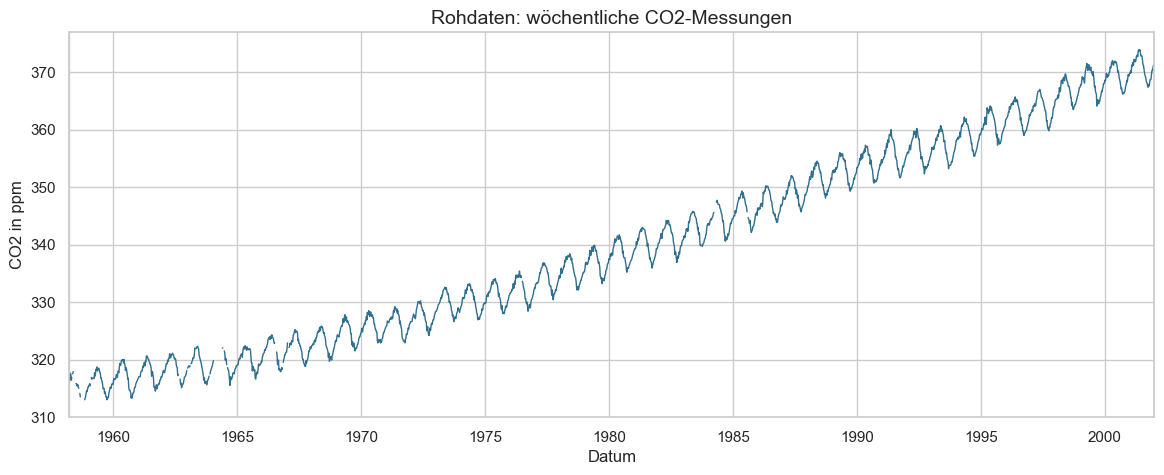

In [150]:
# Plot the raw weekly time series to understand the original data shape.
fig, ax = plt.subplots(figsize=(14, 5))
raw["co2_ppm"].plot(ax=ax, color="#2f6f8f", linewidth=1)
ax.set_title("Rohdaten: wöchentliche CO2-Messungen")
ax.set_xlabel("Datum")
ax.set_ylabel("CO2 in ppm")
plt.show()

Die Rohreihe zeigt bereits zwei zentrale Eigenschaften:

Erstens gibt es einen deutlichen langfristigen Anstieg. Das ist der Trendanteil der Zeitreihe. Zweitens schwanken die Werte regelmäßig innerhalb eines Jahres. Das ist der saisonale Anteil. Zusätzlich enthält die Rohreihe fehlende Werte, die vor einer STL-Zerlegung behandelt werden müssen.

STL kann sehr gut mit komplexen Formen von Trend und Saisonalität umgehen, aber die Methode erwartet eine saubere, regelmäßig indizierte Zeitreihe. Deshalb wechseln wir im nächsten Schritt von wöchentlichen Rohdaten zu monatlichen Mittelwerten und schließen fehlende Werte durch Interpolation.

## 3. Datenvorbereitung

In der Datenvorbereitung machen wir die Zeitreihe STL-fähig. Dafür führen wir vier Schritte aus:

1. Aggregation von wöchentlichen Daten auf monatliche Mittelwerte.
2. Setzen einer eindeutigen monatlichen Frequenz.
3. Interpolation fehlender Werte.
4. Begrenzung auf einen gut interpretierbaren Analysezeitraum.

Die Monatsfrequenz ist didaktisch hilfreich: Eine jährliche Saison entspricht dann genau `period=12`. Dadurch können wir die Parameter `seasonal` und `trend` später leichter interpretieren.

In [151]:
# Aggregate weekly observations to monthly averages.
monthly = raw["co2_ppm"].resample("MS").mean().to_frame()
monthly["co2_ppm"] = monthly["co2_ppm"].interpolate(method="time")
monthly = monthly.asfreq("MS")

# Keep a compact but still rich period for learning and plotting.
series = monthly.loc["1975":"2001", "co2_ppm"].copy()
series.name = "co2_ppm"

# Verify that the prepared series is regular and complete.
print(f"Monthly observations: {len(series)}")
print(f"Frequency: {series.index.freqstr}")
print(f"Missing values after preparation: {series.isna().sum()}")
display(series.head())

Monthly observations: 324
Frequency: MS
Missing values after preparation: 0


1975-01-01    330.250
1975-02-01    331.300
1975-03-01    332.000
1975-04-01    333.275
1975-05-01    333.860
Freq: MS, Name: co2_ppm, dtype: float64

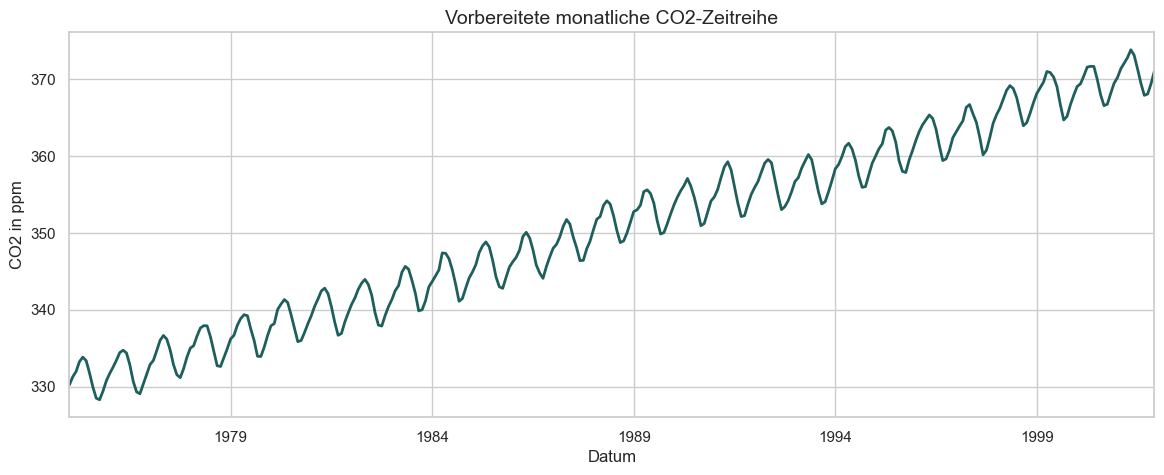

In [152]:
# Visualize the prepared monthly time series.
fig, ax = plt.subplots(figsize=(14, 5))
series.plot(ax=ax, color="#1f5f5b", linewidth=2)
ax.set_title("Vorbereitete monatliche CO2-Zeitreihe")
ax.set_xlabel("Datum")
ax.set_ylabel("CO2 in ppm")
plt.show()

Die vorbereitete Reihe ist regelmäßig, vollständig und monatlich. Damit erfällt sie die wichtigsten technischen Voraussetzungen für STL.

Man erkennt nun sehr klar, warum eine Zerlegung sinnvoll ist: Die Rohzeitreihe enthält gleichzeitig eine steigende Grundbewegung und eine wiederkehrende jährliche Wellenbewegung. Ohne Zerlegung würden beide Effekte übereinanderliegen. STL trennt sie so, dass wir jeden Bestandteil separat interpretieren können.

## 4. Modellierung

In diesem Kapitel liegt der Schwerpunkt des Notebooks. Wir bauen zuerst eine Intuition für LOESS auf und gehen danach Schritt für Schritt zur STL-Zerlegung über.

### 4.1 LOESS-Intuition

LOESS steht für **locally estimated scatterplot smoothing**. Die Grundidee ist einfach:

Statt eine einzige globale Funktion an alle Datenpunkte anzupassen, wird für jeden Zielpunkt eine kleine lokale Regression berechnet. Diese lokale Regression nutzt vor allem Datenpunkte in der Nähe des Zielpunkts. Entfernte Punkte haben wenig oder gar keinen Einfluss.

Man kann sich LOESS wie eine flexible Lupe vorstellen, die entlang der Zeitachse wandert:

- Um jeden Zeitpunkt wird eine Nachbarschaft gewählt.
- Punkte in dieser Nachbarschaft erhalten Gewichte.
- Nahe Punkte erhalten hohe Gewichte.
- Entfernte Punkte erhalten niedrige Gewichte.
- Aus den gewichteten Punkten wird lokal eine einfache Regression geschätzt.
- Der geglättete Wert ist der lokale Vorhersagewert am Zielzeitpunkt.

Dadurch kann LOESS nichtlineare Muster erfassen, ohne eine feste globale Kurvenform vorzugeben.

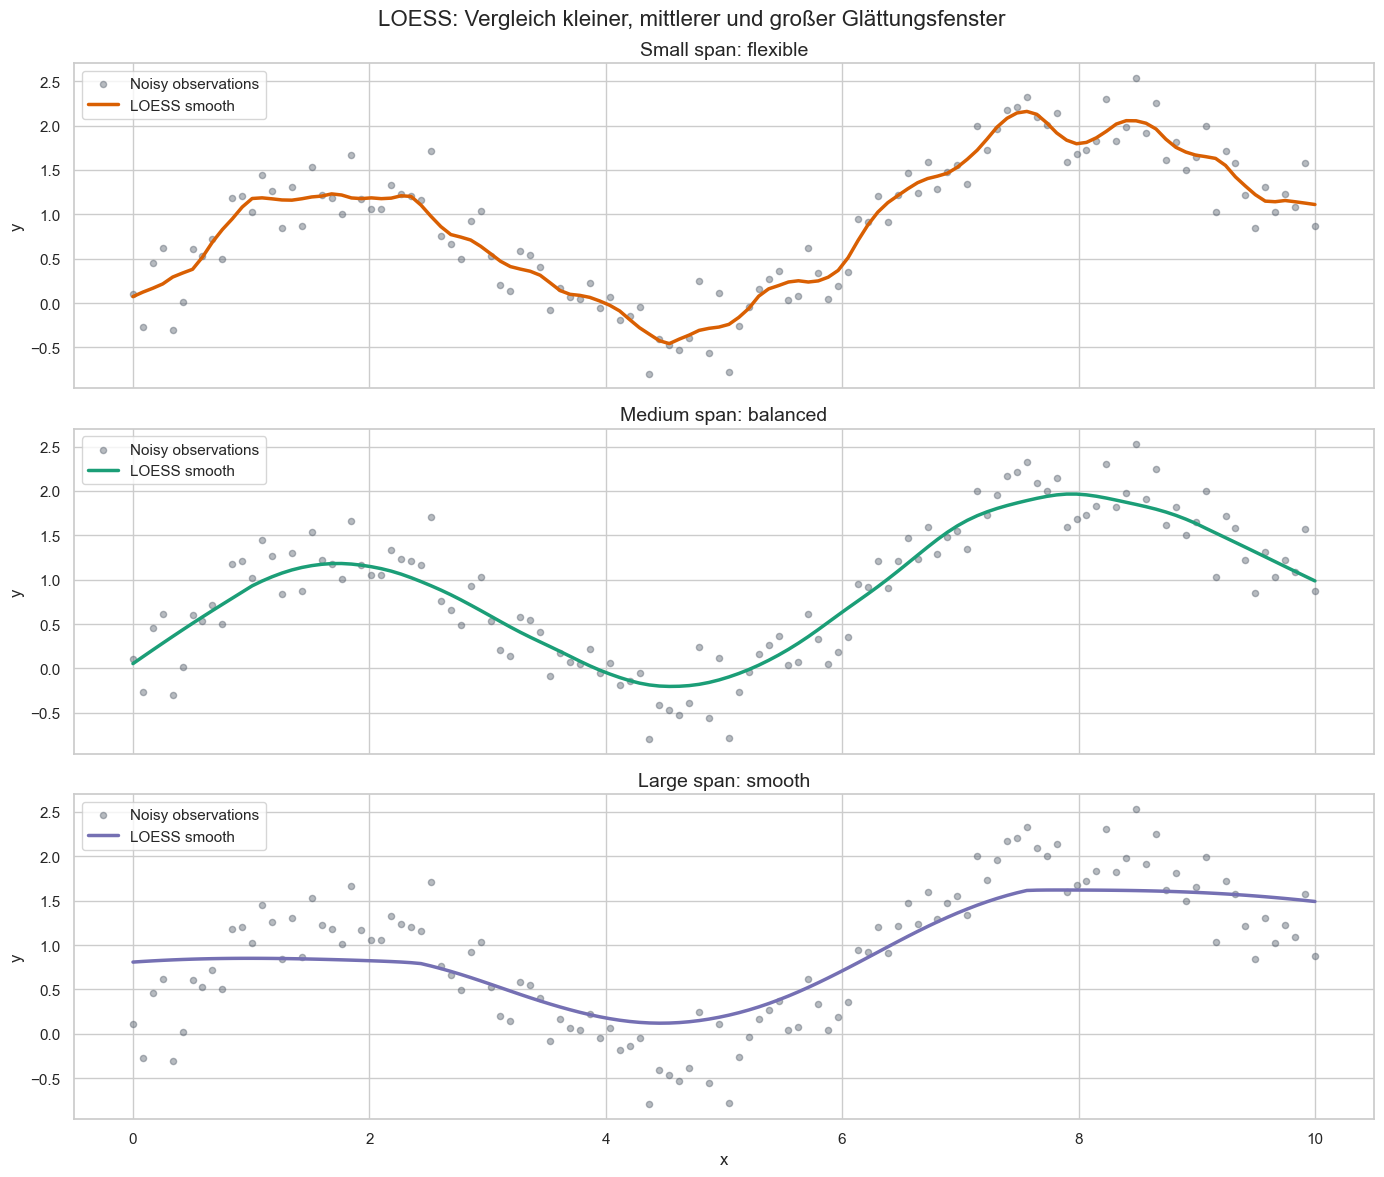

In [153]:
# Create a small noisy example to demonstrate LOESS smoothing.
rng = np.random.default_rng(42)
x = np.linspace(0, 10, 120)
y_true = np.sin(x) + 0.15 * x
y_noisy = y_true + rng.normal(0, 0.35, size=len(x))

# Fit LOESS curves with different spans.
loess_small = lowess(y_noisy, x, frac=0.08, return_sorted=False)
loess_medium = lowess(y_noisy, x, frac=0.22, return_sorted=False)
loess_large = lowess(y_noisy, x, frac=0.50, return_sorted=False)

# Compare the smoothing windows in separate vertical subplots.
loess_settings = [
    ("Small span: flexible", loess_small, "#d95f02"),
    ("Medium span: balanced", loess_medium, "#1b9e77"),
    ("Large span: smooth", loess_large, "#7570b3"),
]

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True, sharey=True)

for ax, (title, loess_curve, color) in zip(axes, loess_settings):
    ax.scatter(x, y_noisy, s=20, alpha=0.40, color="#4b5563", label="Noisy observations")
    ax.plot(x, loess_curve, color=color, linewidth=2.5, label="LOESS smooth")
    ax.set_title(title)
    ax.set_ylabel("y")
    ax.legend(loc="upper left")

axes[-1].set_xlabel("x")
fig.suptitle("LOESS: Vergleich kleiner, mittlerer und großer Glättungsfenster", fontsize=16)
plt.tight_layout()
plt.show()


### 4.2 Lokale Regression, Nachbarschaftsfenster und gewichtete Punkte

LOESS besteht aus drei zentralen Bausteinen.

**Lokale Regression:** Für jeden Punkt wird nicht die gesamte Zeitreihe gleich stark verwendet. Stattdessen wird in der Nähe des Zielpunkts eine kleine Regression berechnet. Meist ist diese Regression linear oder quadratisch.

**Nachbarschaftsfenster:** Das Fenster bestimmt, wie viele benachbarte Punkte in die lokale Regression eingehen. Ein kleines Fenster reagiert stark auf lokale Bewegungen. Ein großes Fenster glättet stärker und ignoriert kurzfristige Schwankungen eher.

**Gewichtete Punkte:** Innerhalb des Fensters sind nicht alle Punkte gleich wichtig. Punkte nahe am Zielpunkt erhalten höhere Gewichte. Punkte weiter entfernt erhalten geringere Gewichte. Typisch ist eine Gewichtsfunktion, die am Rand des Fensters gegen null geht.

Der wichtigste Parameter ist deshalb die Fenstergröße beziehungsweise der **Span**. In `statsmodels.lowess` wird dieser als `frac` angegeben. Ein Wert von `0.20` bedeutet: Für jede lokale Regression werden ungefähr 20 Prozent der Datenpunkte als Nachbarschaft verwendet.

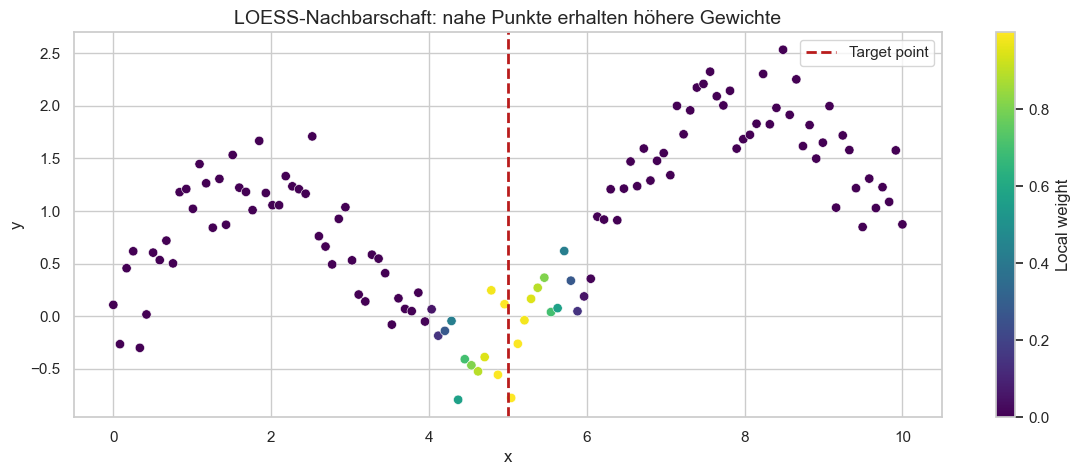

In [154]:
# Visualize the neighborhood and weights for one LOESS target point.
target_x = 5.0
frac = 0.22
n_neighbors = int(np.ceil(frac * len(x)))
distances = np.abs(x - target_x)
max_distance = np.partition(distances, n_neighbors)[n_neighbors]

# Compute tricube weights used conceptually by LOESS.
weights = np.where(
    distances <= max_distance,
    (1 - (distances / max_distance) ** 3) ** 3,
    0,
)

fig, ax = plt.subplots(figsize=(14, 5))
scatter = ax.scatter(x, y_noisy, c=weights, cmap="viridis", s=45, edgecolor="white", linewidth=0.4)
ax.axvline(target_x, color="#b91c1c", linestyle="--", linewidth=2, label="Target point")
ax.set_title("LOESS-Nachbarschaft: nahe Punkte erhalten höhere Gewichte")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend()
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Local weight")
plt.show()

### 4.2.1 Robuste LOESS-Gewichte

Die bisherige LOESS-Erklärung betrachtet vor allem die **Distanzgewichte**: Punkte nahe am Zielpunkt erhalten hohe Gewichte, entfernte Punkte niedrige Gewichte. Robuste LOESS erweitert diese Idee um eine zweite Gewichtung. Nach einer ersten lokalen Glättung werden die Residuen betrachtet. Beobachtungen mit sehr großen Residuen werden als potenzielle Ausreißer behandelt und erhalten ein kleineres robustes Gewicht.

Dadurch entsteht konzeptionell ein kombiniertes Gewicht:

\[
w_{gesamt} = w_{Distanz} \cdot w_{Robust}
\]

Ein Punkt kann also sehr nahe am Zielpunkt liegen und trotzdem wenig Einfluss haben, wenn sein Residuum extrem groß ist. Genau das macht robuste LOESS nützlich, wenn einzelne Ausreißer die lokale Regression verzerren würden.

Im folgenden Beispiel verwenden wir dieselbe synthetische Reihe wie zuvor, fügen aber drei künstliche Ausreißer hinzu. Danach vergleichen wir Standard-LOESS mit robuster LOESS und visualisieren, wie sich die Gewichte verändern.

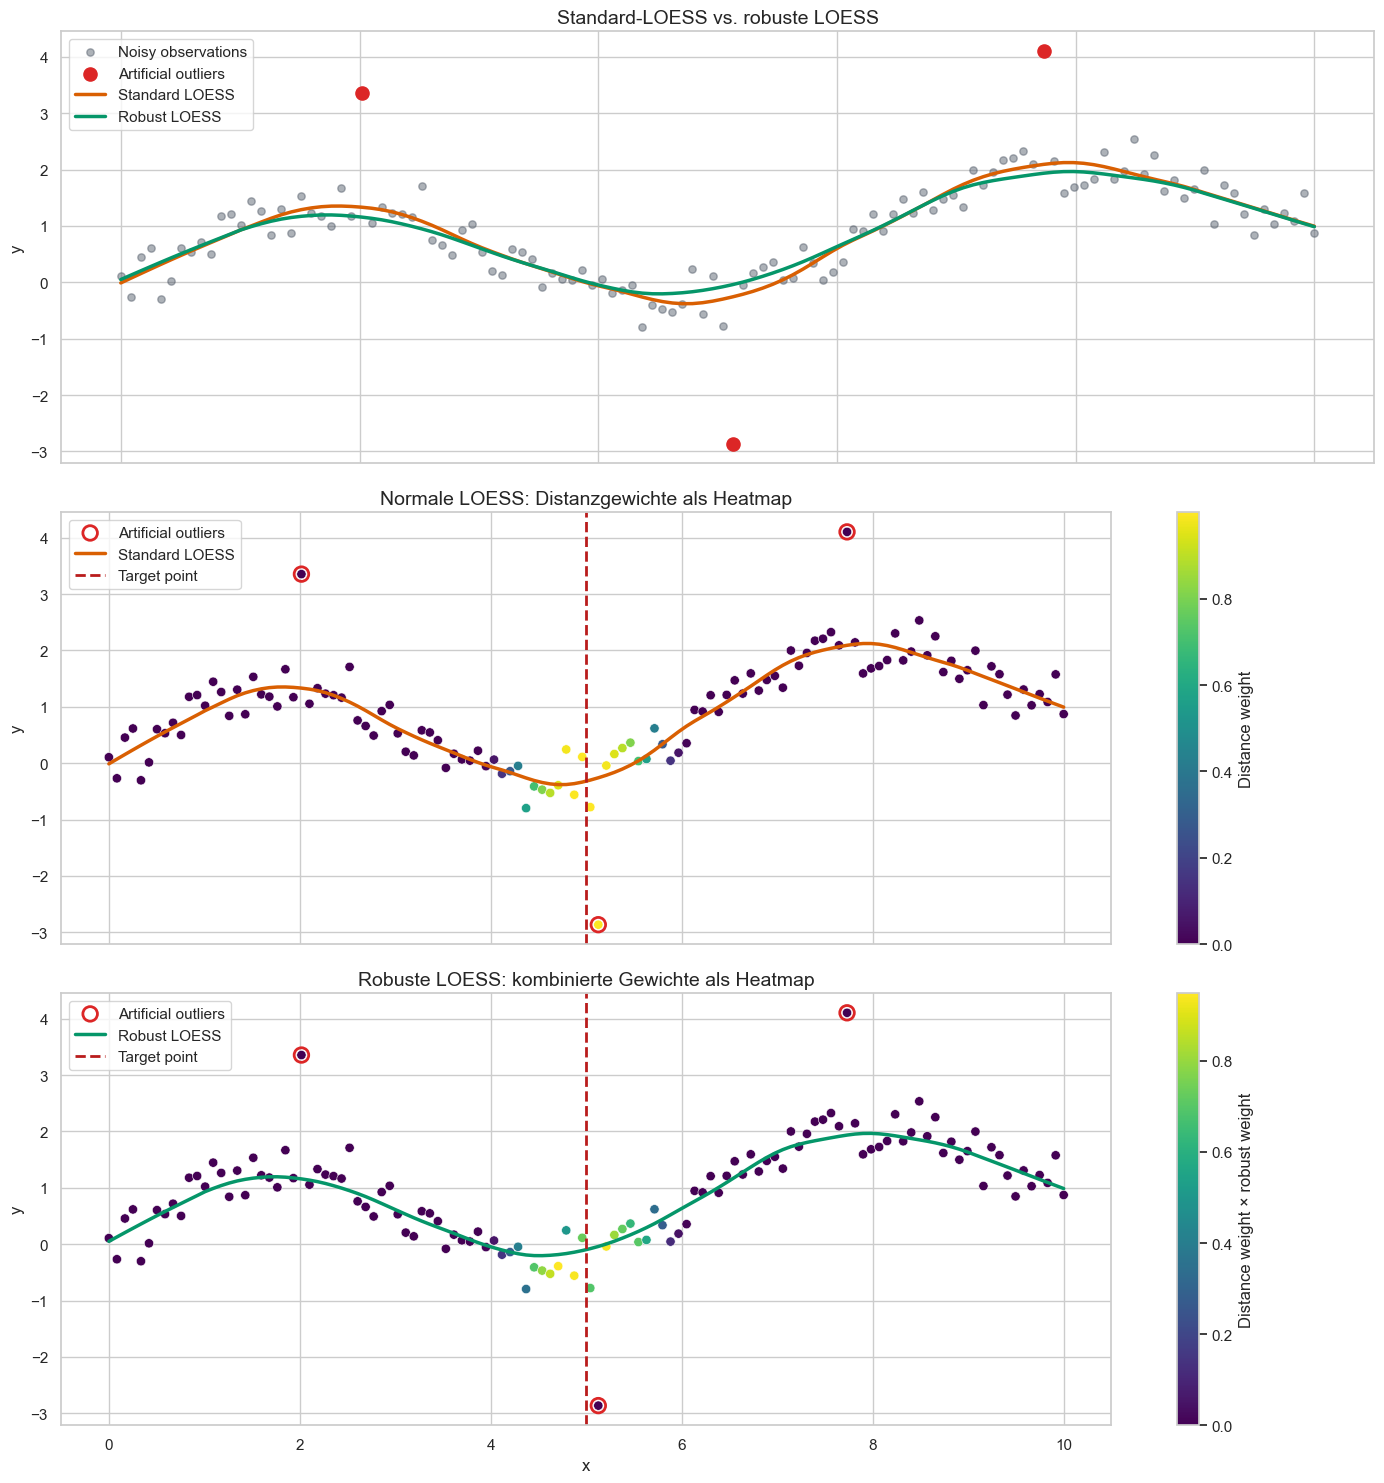

In [155]:
# Study robust LOESS on the same noisy example with artificial outliers.
y_noisy_outliers = y_noisy.copy()
outlier_indices = [24, 61, 92]
outlier_impacts = [2.3, -2.6, 2.1]

for index, impact in zip(outlier_indices, outlier_impacts):
    y_noisy_outliers[index] += impact

# Fit standard and robust LOESS curves.
standard_loess = lowess(y_noisy_outliers, x, frac=0.22, it=0, return_sorted=False)
robust_loess = lowess(y_noisy_outliers, x, frac=0.22, it=3, return_sorted=False)

# Approximate the robust residual weights used after an initial LOESS fit.
residuals = y_noisy_outliers - standard_loess
mad = np.median(np.abs(residuals - np.median(residuals)))
robust_scale = 6 * mad

robust_weights = np.where(
    np.abs(residuals) < robust_scale,
    (1 - (residuals / robust_scale) ** 2) ** 2,
    0,
)

# Combine distance weights around the same target point with robust residual weights.
combined_weights = weights * robust_weights

fig, axes = plt.subplots(3, 1, figsize=(14, 15), sharex=True, sharey=True)

axes[0].scatter(x, y_noisy_outliers, s=28, alpha=0.45, color="#4b5563", label="Noisy observations")
axes[0].scatter(x[outlier_indices], y_noisy_outliers[outlier_indices], s=90, color="#dc2626", label="Artificial outliers")
axes[0].plot(x, standard_loess, color="#d95f02", linewidth=2.5, label="Standard LOESS")
axes[0].plot(x, robust_loess, color="#059669", linewidth=2.5, label="Robust LOESS")
axes[0].set_title("Standard-LOESS vs. robuste LOESS")
axes[0].set_ylabel("y")
axes[0].legend(loc="upper left")

normal_scatter = axes[1].scatter(
    x,
    y_noisy_outliers,
    c=weights,
    cmap="viridis",
    s=45,
    edgecolor="white",
    linewidth=0.4,
)
axes[1].scatter(x[outlier_indices], y_noisy_outliers[outlier_indices], s=110, facecolors="none", edgecolors="#dc2626", linewidth=2, label="Artificial outliers")
axes[1].plot(x, standard_loess, color="#d95f02", linewidth=2.5, label="Standard LOESS")
axes[1].axvline(target_x, color="#b91c1c", linestyle="--", linewidth=2, label="Target point")
axes[1].set_title("Normale LOESS: Distanzgewichte als Heatmap")
axes[1].set_ylabel("y")
axes[1].legend(loc="upper left")
cbar = plt.colorbar(normal_scatter, ax=axes[1])
cbar.set_label("Distance weight")

robust_scatter = axes[2].scatter(
    x,
    y_noisy_outliers,
    c=combined_weights,
    cmap="viridis",
    s=45,
    edgecolor="white",
    linewidth=0.4,
)
axes[2].scatter(x[outlier_indices], y_noisy_outliers[outlier_indices], s=110, facecolors="none", edgecolors="#dc2626", linewidth=2, label="Artificial outliers")
axes[2].plot(x, robust_loess, color="#059669", linewidth=2.5, label="Robust LOESS")
axes[2].axvline(target_x, color="#b91c1c", linestyle="--", linewidth=2, label="Target point")
axes[2].set_title("Robuste LOESS: kombinierte Gewichte als Heatmap")
axes[2].set_xlabel("x")
axes[2].set_ylabel("y")
axes[2].legend(loc="upper left")
cbar = plt.colorbar(robust_scatter, ax=axes[2])
cbar.set_label("Distance weight × robust weight")

plt.tight_layout()
plt.show()


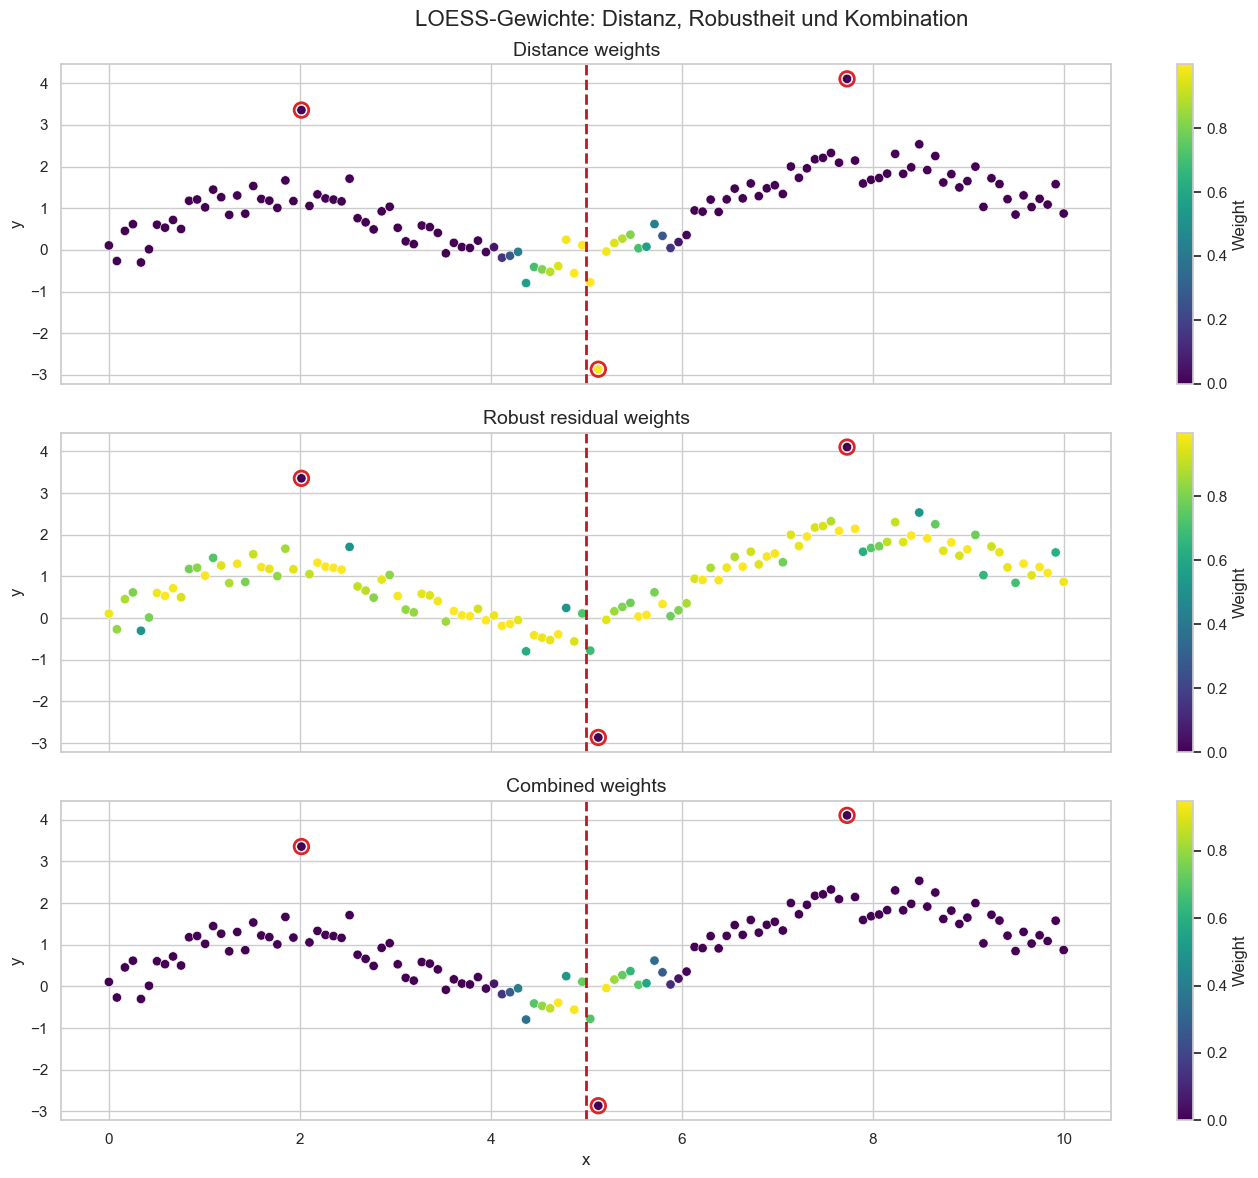

In [156]:
# Compare distance, robust, and combined weights for the same target point.
weight_panels = [
    ("Distance weights", weights),
    ("Robust residual weights", robust_weights),
    ("Combined weights", combined_weights),
]

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True, sharey=True)

for ax, (title, panel_weights) in zip(axes, weight_panels):
    scatter = ax.scatter(
        x,
        y_noisy_outliers,
        c=panel_weights,
        cmap="viridis",
        s=45,
        edgecolor="white",
        linewidth=0.4,
    )
    ax.scatter(x[outlier_indices], y_noisy_outliers[outlier_indices], s=110, facecolors="none", edgecolors="#dc2626", linewidth=2)
    ax.axvline(target_x, color="#b91c1c", linestyle="--", linewidth=2)
    ax.set_title(title)
    ax.set_ylabel("y")
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label("Weight")

axes[-1].set_xlabel("x")
fig.suptitle("LOESS-Gewichte: Distanz, Robustheit und Kombination", fontsize=16)
plt.tight_layout()
plt.show()


### 4.3 LOESS-Fenstergröße: klein, mittel, groß

Die Fenstergröße steuert den Bias-Varianz-Kompromiss:

- Ein **kleines Fenster** folgt lokalen Bewegungen sehr stark. Das kann hilfreich sein, wenn die Struktur wirklich schnell wechselt. Es kann aber auch Rauschen als Signal interpretieren.
- Ein **mittleres Fenster** ist häufig ein guter Kompromiss. Es glättet zufällige Schwankungen, bleibt aber beweglich genug für echte Änderungen.
- Ein **großes Fenster** erzeugt eine sehr ruhige Kurve. Es ist stabil, kann aber Wendepunkte und lokale Muster zu stark verschleifen.

Für STL ist diese Idee entscheidend, weil STL intern wiederholt LOESS-Glättungen verwendet: für saisonale Teilreihen, für den Trend und optional für robuste Gewichtungen gegen Ausreißer.

### 4.4 STL Schritt für Schritt

STL zerlegt eine Zeitreihe in Trend, Saison und Rest. Konzeptionell läuft die Methode iterativ. Vereinfacht kann man den Ablauf so verstehen:

1. **Detrend:** Entferne eine aktuelle Trendschätzung aus der Reihe.
2. **Saison schätzen:** Schätze das saisonale Muster auf der detrendeten Reihe.
3. **Saison entfernen:** Ziehe die geschätzte Saison von der Originalreihe ab.
4. **Trend aktualisieren:** Glätte die saisonbereinigte Reihe, um den Trend zu aktualisieren.
5. **Residual berechnen:** Was nach Trend und Saison übrig bleibt, ist der Rest.
6. **Wiederholen:** Diese Schritte werden mehrfach wiederholt, bis die Komponenten stabil sind.

Die Stärke von STL liegt darin, dass der saisonale Verlauf nicht starr sein muss. Im Gegensatz zu einfachen klassischen Zerlegungen kann sich die Saisonalität langsam über die Zeit verändern.

In [157]:
# Fit a baseline STL model.
baseline_stl = STL(series, period=12, seasonal=13, trend=25, robust=False)
baseline_result = baseline_stl.fit()

# Combine the decomposition components in one DataFrame.
components = pd.DataFrame({
    "observed": series,
    "trend": baseline_result.trend,
    "seasonal": baseline_result.seasonal,
    "resid": baseline_result.resid,
})

display(components.head())

,observed,trend,seasonal,resid
1975-01-01,330.250,330.509137,-0.017640,-0.241497
1975-02-01,331.300,330.612902,0.550774,0.136324
1975-03-01,332.000,330.715865,1.462902,-0.178767
1975-04-01,333.275,330.817991,2.428115,0.028893
1975-05-01,333.860,330.919287,2.806956,0.133757


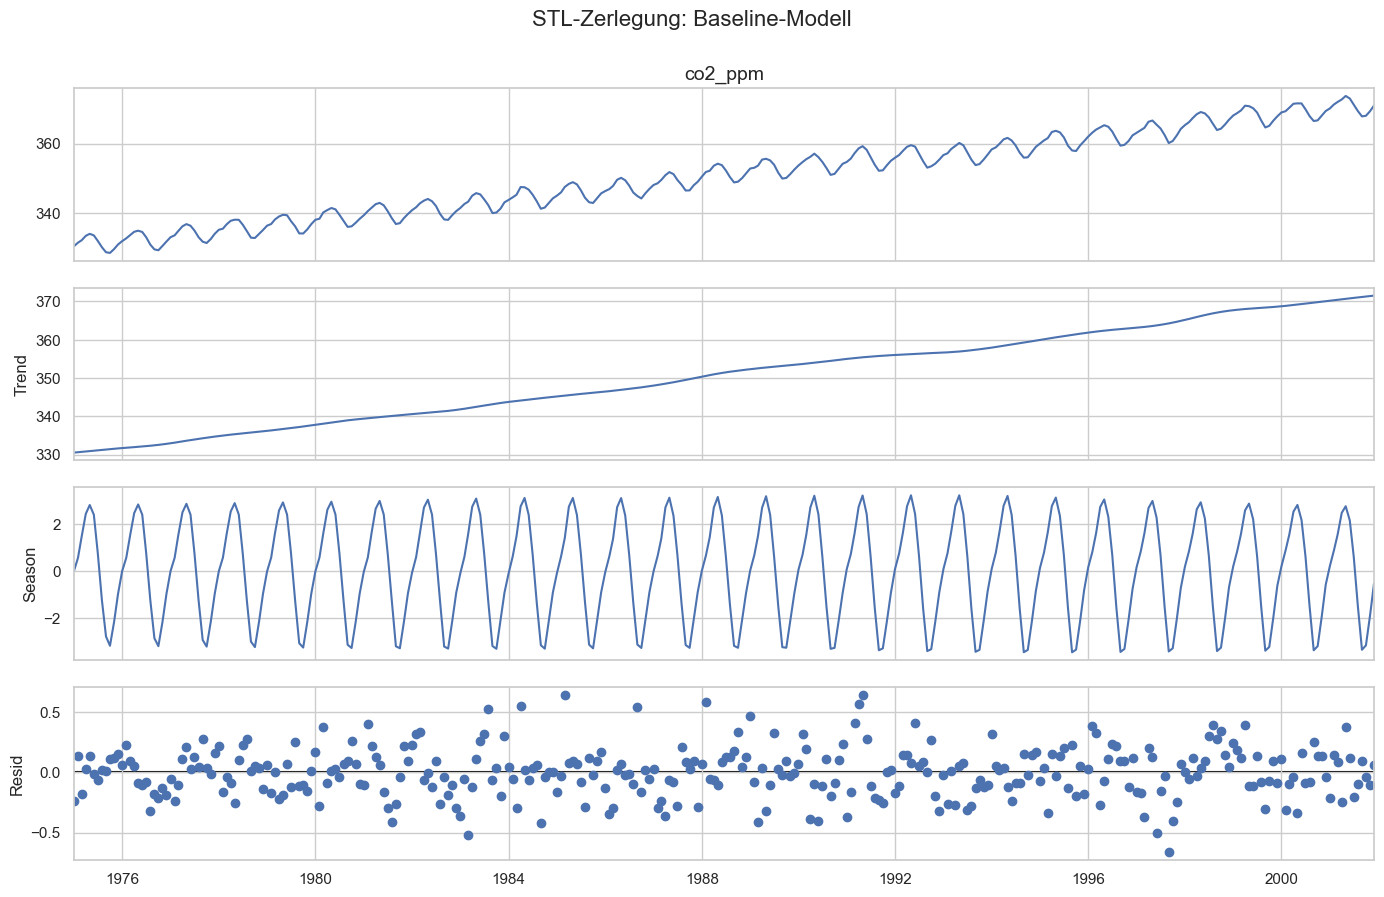

In [158]:
# Plot the baseline STL decomposition.
fig = baseline_result.plot()
fig.set_size_inches(14, 9)
fig.suptitle("STL-Zerlegung: Baseline-Modell", y=1.02, fontsize=16)
plt.show()

Die vier Grafiken zeigen die STL-Zerlegung:

- **Observed:** die ursprüngliche Zeitreihe.
- **Trend:** die langfristige Grundbewegung.
- **Seasonal:** das wiederkehrende saisonale Muster innerhalb eines Jahres.
- **Resid:** der Rest, der nicht durch Trend oder Saison erklärt wird.

Eine gute Zerlegung erkennt man nicht daran, dass die Residuen perfekt null sind. Eine gute Zerlegung erkennt man daran, dass Trend und Saison fachlich plausibel sind und die Residuen möglichst wenig systematische Struktur enthalten.

### 4.5 Eine didaktische STL-Näherung: Detrend, Saison, Trend, Residuum

Die echte STL-Implementierung ist algorithmisch anspruchsvoller als eine einfache Lehrbuchrechnung. Trotzdem hilft eine vereinfachte Annäherung, die innere Logik zu sehen.

Im folgenden Code zerlegen wir die Reihe grob von Hand:

1. Wir schätzen einen ersten Trend mit einem rollierenden Mittelwert.
2. Wir entfernen diesen Trend.
3. Wir berechnen für jeden Monat ein durchschnittliches saisonales Muster.
4. Wir entfernen die Saison aus der Originalreihe.
5. Wir schätzen den Trend erneut auf der saisonbereinigten Reihe.
6. Wir berechnen das Residuum.

Diese manuelle Variante ersetzt STL nicht, macht aber den Denkprozess transparent.

In [159]:
# Build a simplified educational STL-like decomposition.
manual = pd.DataFrame({"observed": series})

# Step 1: estimate an initial trend with a centered rolling average.
manual["initial_trend"] = manual["observed"].rolling(window=25, center=True, min_periods=12).mean()
manual["initial_trend"] = manual["initial_trend"].interpolate().bfill().ffill()

# Step 2: remove the initial trend.
manual["detrended"] = manual["observed"] - manual["initial_trend"]

# Step 3: estimate a monthly seasonal pattern from the detrended values.
month_effect = manual["detrended"].groupby(manual.index.month).mean()
month_effect = month_effect - month_effect.mean()
manual["seasonal_estimate"] = [month_effect[m] for m in manual.index.month]

# Step 4: remove the seasonal estimate.
manual["seasonally_adjusted"] = manual["observed"] - manual["seasonal_estimate"]

# Step 5: update the trend using the seasonally adjusted series.
manual["updated_trend"] = manual["seasonally_adjusted"].rolling(window=25, center=True, min_periods=12).mean()
manual["updated_trend"] = manual["updated_trend"].interpolate().bfill().ffill()

# Step 6: compute residuals.
manual["residual"] = manual["observed"] - manual["updated_trend"] - manual["seasonal_estimate"]

manual.head()

,observed,initial_trend,detrended,seasonal_estimate,seasonally_adjusted,updated_trend,residual
1975-01-01,330.250,331.128462,-0.878462,0.007527,330.242473,331.127883,-0.885409
1975-02-01,331.300,331.230000,0.070000,0.633326,330.666674,331.184225,-0.517551
1975-03-01,332.000,331.378000,0.622000,1.472207,330.527793,331.237129,-0.709336
1975-04-01,333.275,331.570000,1.705000,2.540170,330.734830,331.279173,-0.544343
1975-05-01,333.860,331.757647,2.102353,2.903597,330.956403,331.313128,-0.356725


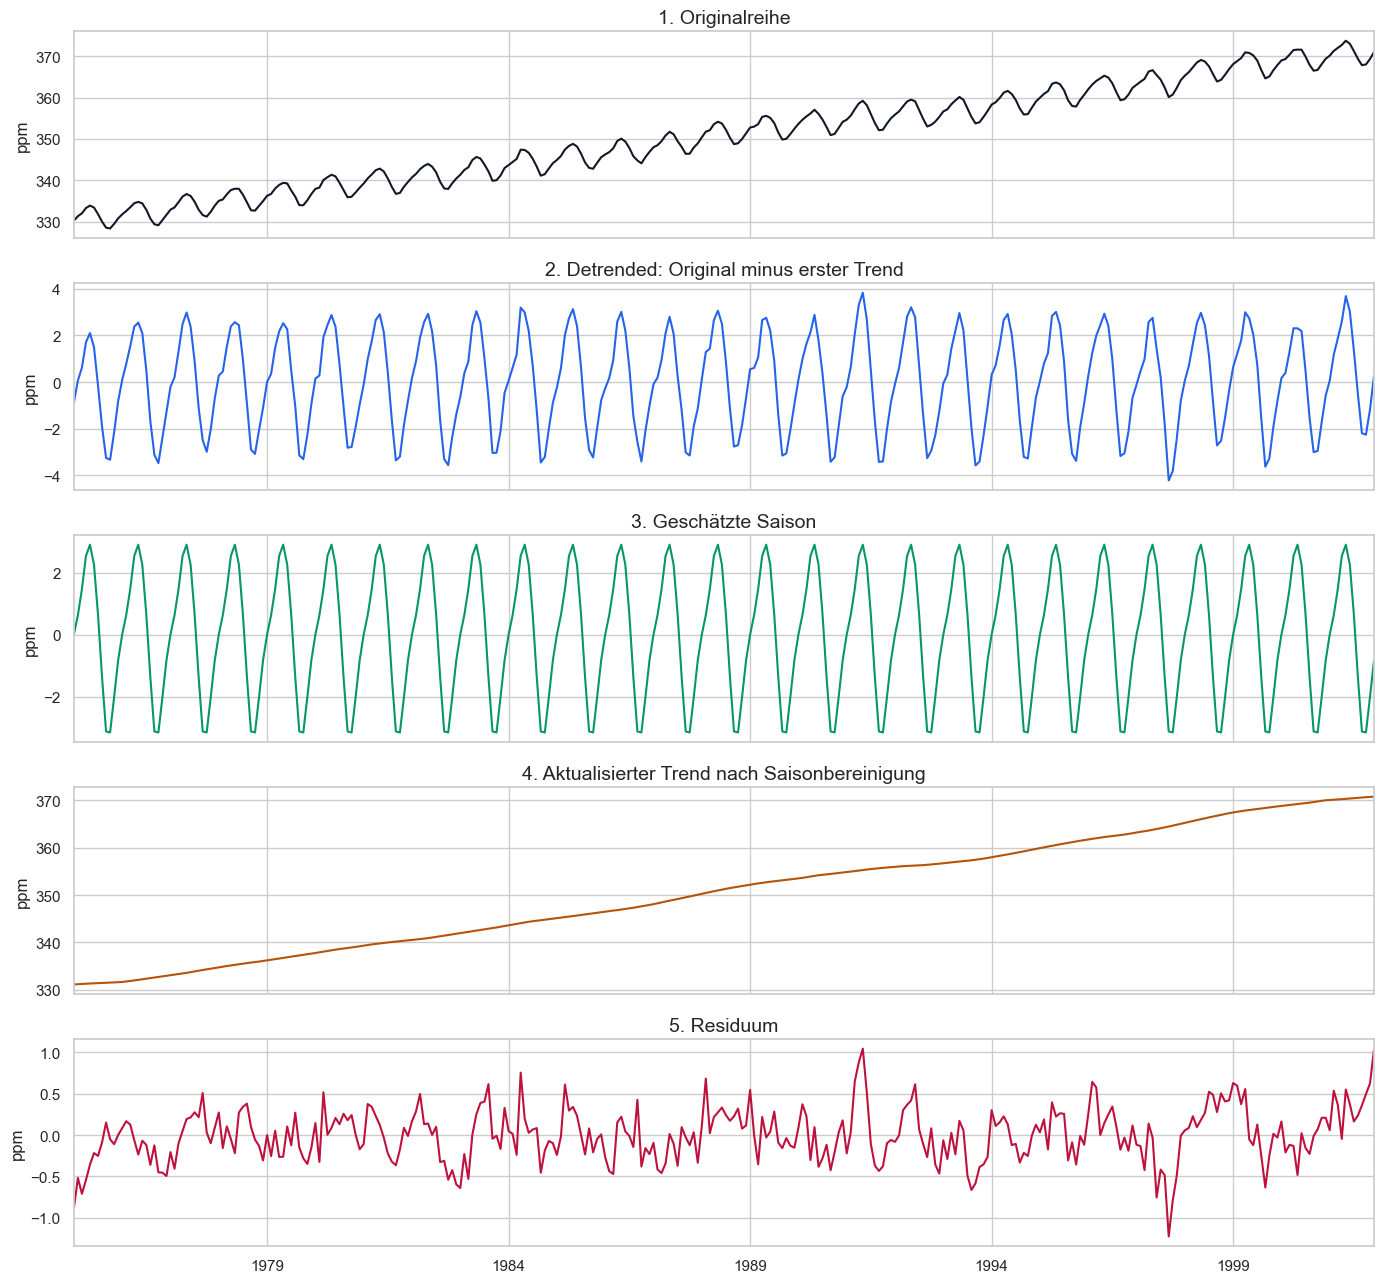

In [160]:
# Plot the simplified step-by-step decomposition.
fig, axes = plt.subplots(5, 1, figsize=(14, 13), sharex=True)
manual["observed"].plot(ax=axes[0], color="#111827", title="1. Originalreihe")
manual["detrended"].plot(ax=axes[1], color="#2563eb", title="2. Detrended: Original minus erster Trend")
manual["seasonal_estimate"].plot(ax=axes[2], color="#059669", title="3. Geschätzte Saison")
manual["updated_trend"].plot(ax=axes[3], color="#b45309", title="4. Aktualisierter Trend nach Saisonbereinigung")
manual["residual"].plot(ax=axes[4], color="#be123c", title="5. Residuum")

for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("ppm")

plt.tight_layout()
plt.show()

Die vereinfachte Zerlegung zeigt die Kernlogik von STL. Zuerst wird Trend entfernt, damit die Saison nicht durch den langfristigen Anstieg verzerrt wird. Danach wird die Saison entfernt, damit der Trend nicht durch wiederkehrende Monatsmuster verzerrt wird. Am Ende bleibt ein Residuum übrig.

Die echte STL-Methode macht dies feiner und iterativer. Sie nutzt LOESS statt einfacher rollierender Mittelwerte und kann robuste Gewichtungen verwenden, damit Ausreißer die Komponenten weniger stark beeinflussen.

### 4.6 Parameterstudie: `seasonal`, `trend`, `robust`

Die wichtigsten STL-Parameter in diesem Notebook sind:

**`period=12`** gibt die Länge eines vollständigen saisonalen Zyklus an. Bei Monatsdaten und jährlicher Saisonalität ist das `12`.

**`seasonal`** bestimmt, wie stark die saisonale Komponente geglättet wird. Der Wert muss ungerade sein. Kleinere Werte erlauben flexiblere saisonale VerÄnderungen. Größere Werte erzeugen stabilere saisonale Muster.

**`trend`** bestimmt die Glättung des Trends. Auch dieser Wert ist typischerweise ungerade. Ein kleinerer Wert macht den Trend beweglicher. Ein größerer Wert macht ihn glatter.

**`robust`** aktiviert robuste Gewichtung. Dadurch werden Ausreißer während der Schätzung weniger stark berücksichtigt. Das ist besonders wichtig, wenn einzelne extreme Beobachtungen Trend oder Saison verzerren könnten.

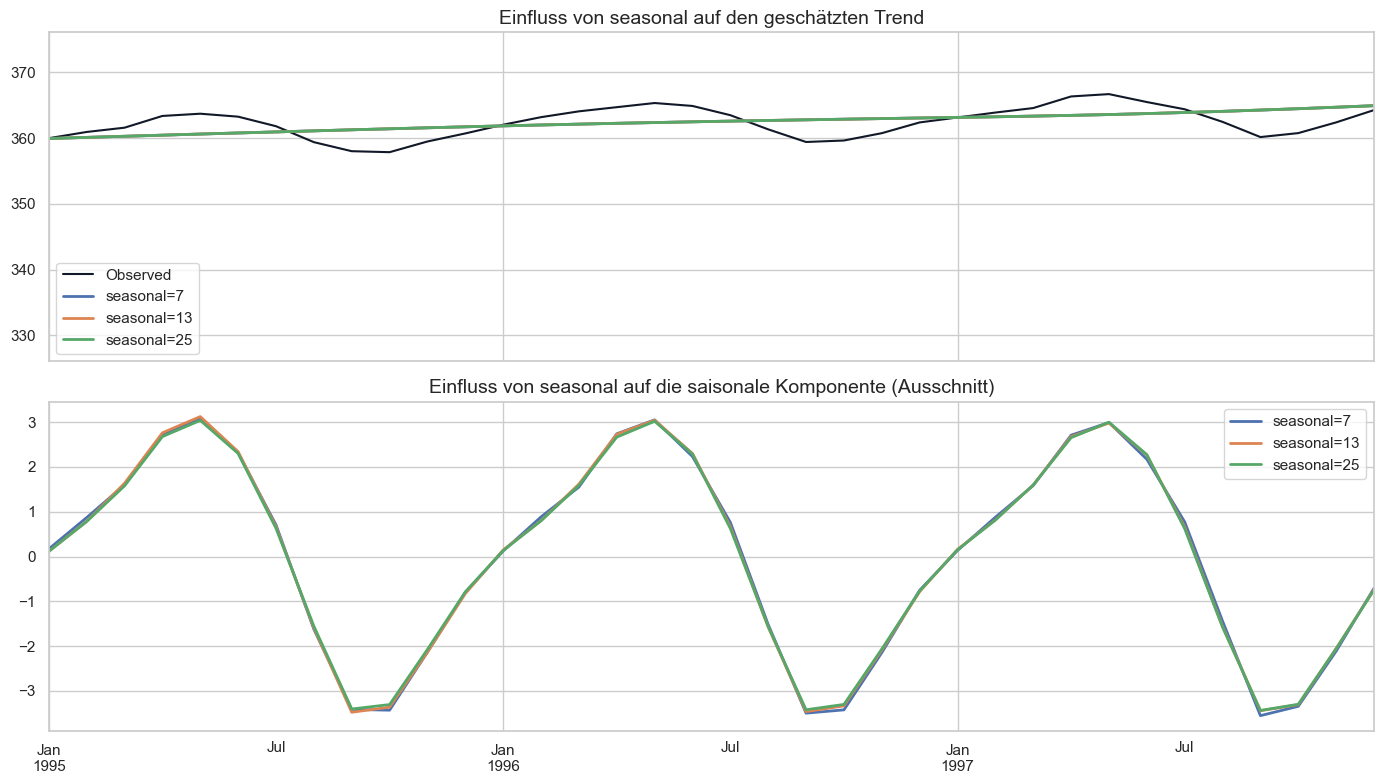

In [161]:
# Compare different seasonal smoothing windows while keeping the trend fixed.
seasonal_values = [7, 13, 25]
seasonal_results = {}

for seasonal_window in seasonal_values:
    model = STL(series, period=12, seasonal=seasonal_window, trend=25, robust=False)
    seasonal_results[seasonal_window] = model.fit()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
series.plot(ax=axes[0], color="#111827", linewidth=1.5, label="Observed")
for seasonal_window, result in seasonal_results.items():
    result.trend.plot(ax=axes[0], linewidth=2, label=f"seasonal={seasonal_window}")
axes[0].set_title("Einfluss von seasonal auf den geschätzten Trend")
axes[0].legend()

for seasonal_window, result in seasonal_results.items():
    result.seasonal.loc["1995":"1997"].plot(ax=axes[1], linewidth=2, label=f"seasonal={seasonal_window}")
axes[1].set_title("Einfluss von seasonal auf die saisonale Komponente (Ausschnitt)")
axes[1].legend()
plt.tight_layout()
plt.show()

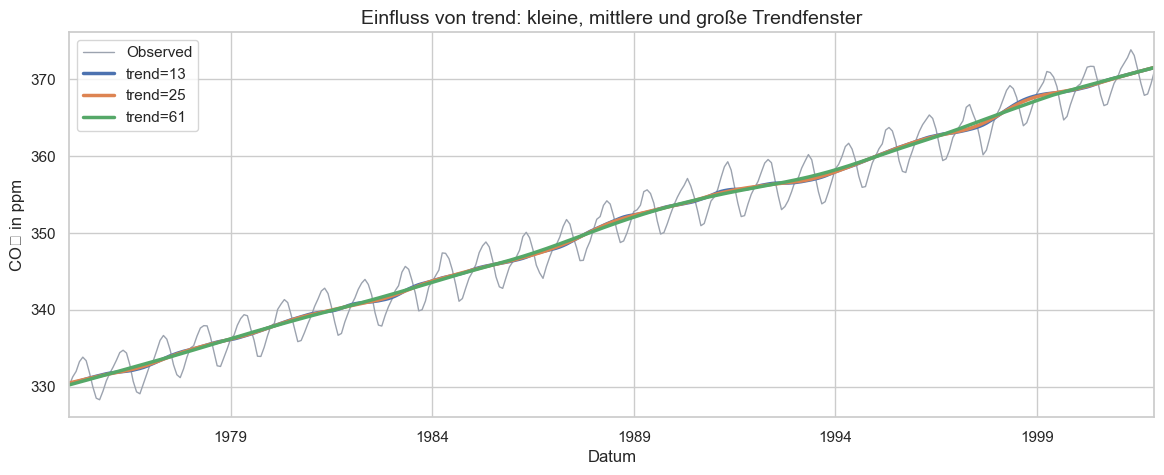

In [162]:
# Compare different trend smoothing windows while keeping seasonal fixed.
trend_values = [13, 25, 61]
trend_results = {}

for trend_window in trend_values:
    model = STL(series, period=12, seasonal=13, trend=trend_window, robust=False)
    trend_results[trend_window] = model.fit()

fig, ax = plt.subplots(figsize=(14, 5))
series.plot(ax=ax, color="#9ca3af", linewidth=1, label="Observed")
for trend_window, result in trend_results.items():
    result.trend.plot(ax=ax, linewidth=2.5, label=f"trend={trend_window}")
ax.set_title("Einfluss von trend: kleine, mittlere und große Trendfenster")
ax.set_xlabel("Datum")
ax.set_ylabel("CO₂ in ppm")
ax.legend()
plt.show()

Die Parameterstudie macht sichtbar, dass STL nicht einfach eine einzige Zerlegung liefert. Die Zerlegung hängt von Modellierungsentscheidungen ab.

Bei kleineren Fenstern bewegen sich Trend und Saison stärker mit lokalen Schwankungen. Bei größeren Fenstern werden die Komponenten ruhiger. Es gibt daher nicht immer den einen objektiv richtigen Wert. Die Wahl hängt vom fachlichen Ziel ab:

- Für Erklärung und Kommunikation sind glattere Komponenten oft verständlicher.
- Für frühe Erkennung lokaler Änderungen können flexiblere Komponenten sinnvoll sein.
- Für Prognosemodelle sollte geprüft werden, welche Zerlegung auf Validierungsdaten besser funktioniert.

### 4.7 Standard-STL versus robuste STL bei Ausreißern

Ein wichtiges Lernziel ist der Unterschied zwischen Standard-STL und robuster STL. Standard-STL behandelt jeden Punkt grundsätzlich als normale Beobachtung. Wenn einzelne Werte stark ausreißen, können sie Trend und Saison sichtbar verzerren.

Robuste STL nutzt zusätzliche Gewichtungen. Beobachtungen mit großen Residuen erhalten im Laufe der Iterationen geringere Gewichte. Dadurch beeinflussen Ausreißer die geschätzten Komponenten weniger stark.

Wir erzeugen nun künstliche Ausreißer in der Zeitreihe und vergleichen:

- Standard-STL auf der Reihe mit Ausreißern
- robuste STL auf der Reihe mit Ausreißern
- Referenz-STL auf der ursprünglichen sauberen Reihe

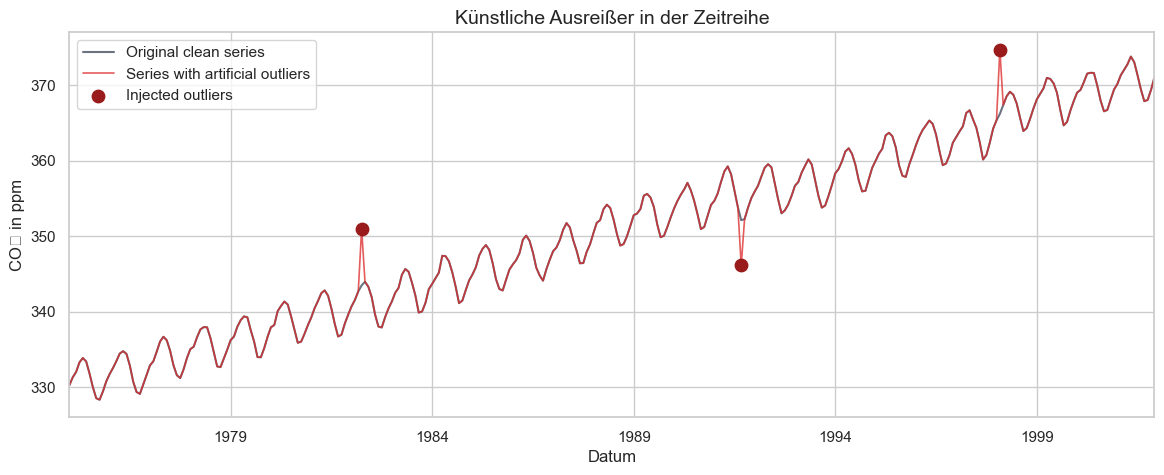

In [163]:
# Inject artificial outliers to test robust STL behavior.
series_outliers = series.copy()
outlier_dates = pd.to_datetime(["1982-04-01", "1991-09-01", "1998-02-01"])
outlier_impacts = [7.5, -6.0, 8.5]

for date, impact in zip(outlier_dates, outlier_impacts):
    series_outliers.loc[date] += impact

# Fit reference, standard, and robust STL decompositions.
reference = STL(series, period=12, seasonal=13, trend=25, robust=False).fit()
standard_outlier = STL(series_outliers, period=12, seasonal=13, trend=25, robust=False).fit()
robust_outlier = STL(series_outliers, period=12, seasonal=13, trend=25, robust=True).fit()

fig, ax = plt.subplots(figsize=(14, 5))
series.plot(ax=ax, color="#6b7280", linewidth=1.5, label="Original clean series")
series_outliers.plot(ax=ax, color="#dc2626", linewidth=1.2, alpha=0.75, label="Series with artificial outliers")
ax.scatter(outlier_dates, series_outliers.loc[outlier_dates], color="#991b1b", s=80, zorder=5, label="Injected outliers")
ax.set_title("Künstliche Ausreißer in der Zeitreihe")
ax.set_xlabel("Datum")
ax.set_ylabel("CO₂ in ppm")
ax.legend()
plt.show()

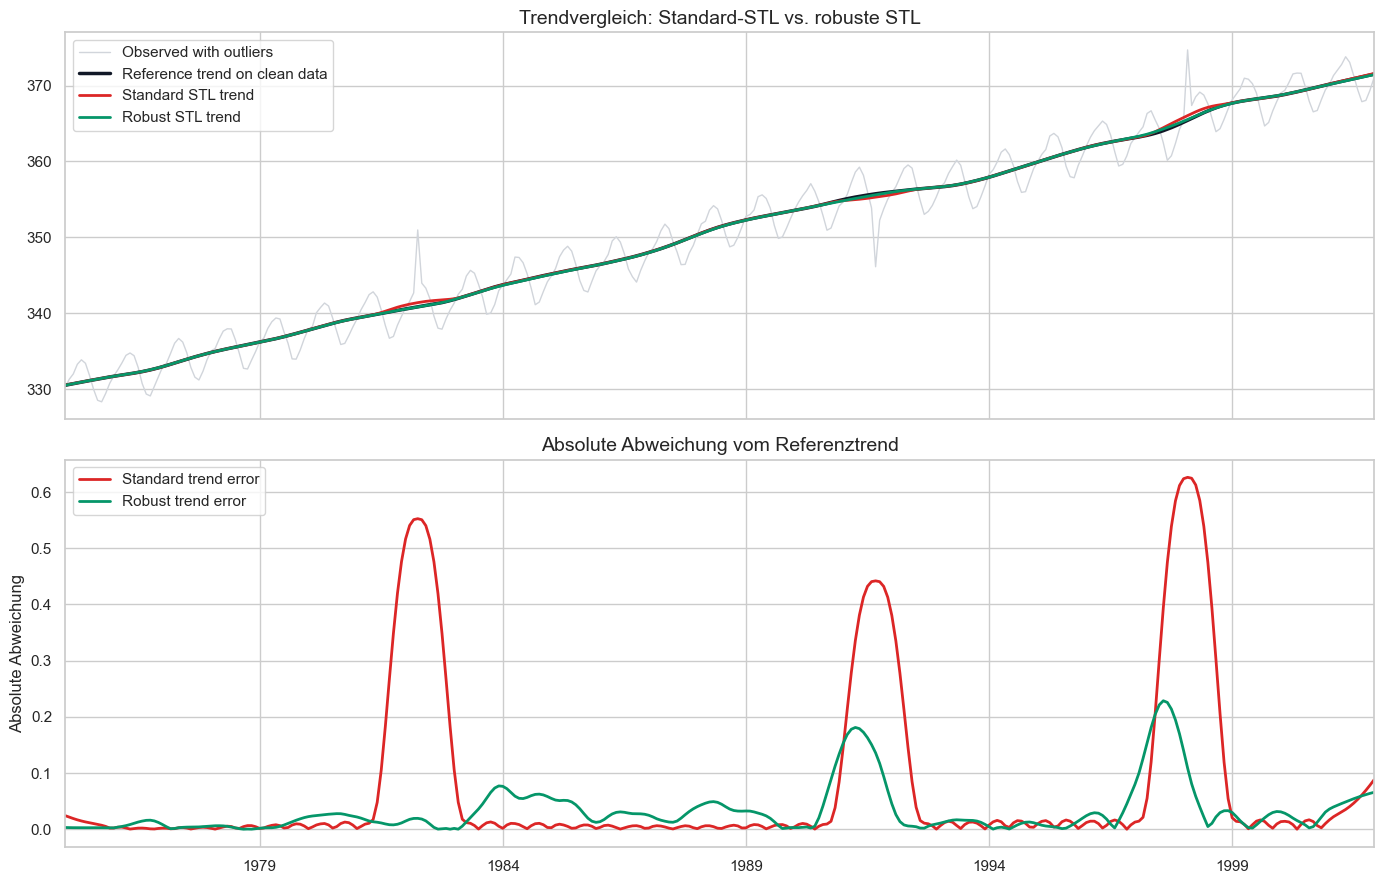

In [164]:
# Compare trend estimates under outlier contamination.
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

series_outliers.plot(ax=axes[0], color="#d1d5db", linewidth=1, label="Observed with outliers")
reference.trend.plot(ax=axes[0], color="#111827", linewidth=2.5, label="Reference trend on clean data")
standard_outlier.trend.plot(ax=axes[0], color="#dc2626", linewidth=2, label="Standard STL trend")
robust_outlier.trend.plot(ax=axes[0], color="#059669", linewidth=2, label="Robust STL trend")
axes[0].set_title("Trendvergleich: Standard-STL vs. robuste STL")
axes[0].legend()

(reference.trend - standard_outlier.trend).abs().plot(ax=axes[1], color="#dc2626", linewidth=2, label="Standard trend error")
(reference.trend - robust_outlier.trend).abs().plot(ax=axes[1], color="#059669", linewidth=2, label="Robust trend error")
axes[1].set_title("Absolute Abweichung vom Referenztrend")
axes[1].set_ylabel("Absolute Abweichung")
axes[1].legend()

plt.tight_layout()
plt.show()

In [165]:
# Quantify component deviations from the clean reference decomposition.
def mae(a, b):
    return np.mean(np.abs(np.asarray(a) - np.asarray(b)))

comparison = pd.DataFrame({
    "component": ["trend", "seasonal", "resid"],
    "standard_stl_mae": [
        mae(reference.trend, standard_outlier.trend),
        mae(reference.seasonal, standard_outlier.seasonal),
        mae(reference.resid, standard_outlier.resid),
    ],
    "robust_stl_mae": [
        mae(reference.trend, robust_outlier.trend),
        mae(reference.seasonal, robust_outlier.seasonal),
        mae(reference.resid, robust_outlier.resid),
    ],
})

comparison["robust_improvement_%"] = (
    (comparison["standard_stl_mae"] - comparison["robust_stl_mae"])
    / comparison["standard_stl_mae"]
    * 100
)

comparison

,component,standard_stl_mae,robust_stl_mae,robust_improvement_%
0,trend,0.074691,0.032601,56.352630
1,seasonal,0.121465,0.037353,69.248171
2,resid,0.199017,0.116248,41.588872


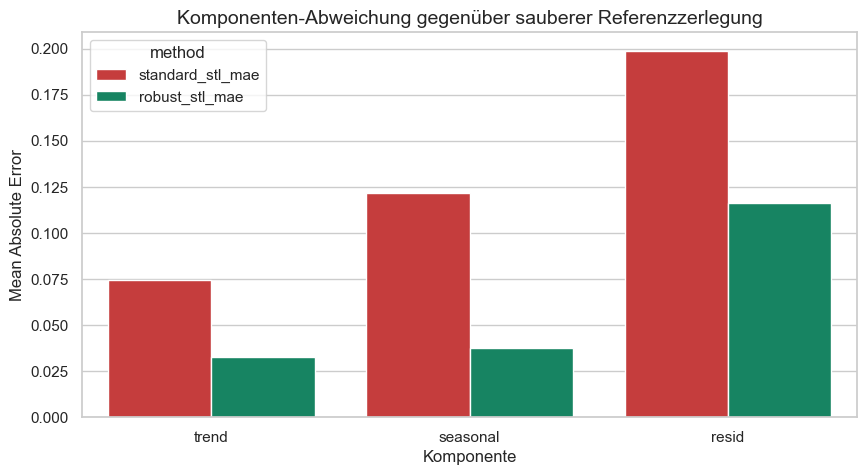

In [166]:
# Visualize the MAE comparison for standard and robust STL.
comparison_long = comparison.melt(
    id_vars="component",
    value_vars=["standard_stl_mae", "robust_stl_mae"],
    var_name="method",
    value_name="mae",
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=comparison_long, x="component", y="mae", hue="method", ax=ax, palette=["#dc2626", "#059669"])
ax.set_title("Komponenten-Abweichung gegenüber sauberer Referenzzerlegung")
ax.set_xlabel("Komponente")
ax.set_ylabel("Mean Absolute Error")
plt.show()

Die robuste STL sollte bei den künstlichen Ausreißern meist näher an der Referenzzerlegung liegen als Standard-STL. Besonders beim Trend ist dieser Unterschied wichtig: Ein einzelner extremer Wert sollte die langfristige Grundbewegung nicht stark verändern.

Wichtig ist aber auch: `robust=True` ist kein Ersatz für fachliches Datenverständnis. Wenn ein Ausreißer ein echter struktureller Effekt ist, sollte er nicht automatisch ignoriert werden. Robuste STL ist besonders sinnvoll, wenn einzelne Messfehler, Einmaleffekte oder extreme Ereignisse die Komponenten nicht dominieren sollen.

## 5. Evaluation

Im CRISP-DM-Schritt Evaluation prüfen wir, ob die Modellierung die ursprüngliche Fragestellung beantwortet. Bei einer STL-Zerlegung gibt es dafür keine einzige universelle Kennzahl. Stattdessen kombinieren wir visuelle, statistische und fachliche Kriterien.

Eine brauchbare STL-Zerlegung sollte folgende Eigenschaften haben:

- Der Trend ist glatt genug, um die langfristige Entwicklung zu zeigen.
- Die saisonale Komponente enthält wiederkehrende Muster und keinen starken Trend.
- Die Residuen enthalten möglichst wenig offensichtliche Struktur.
- Ausreißer verzerren die Komponenten nicht übermäßig.
- Die Parameterwahl ist fachlich erklärbar.

Wir prüfen nun die Residuen der Baseline-Zerlegung genauer.

In [167]:
# Evaluate residual behavior from the baseline STL model.
resid = baseline_result.resid.dropna()

summary = pd.Series({
    "mean": resid.mean(),
    "std": resid.std(),
    "min": resid.min(),
    "max": resid.max(),
    "mae": np.mean(np.abs(resid)),
})
summary

mean   -0.000433
std     0.207588
min    -0.660247
max     0.637581
mae     0.161216
dtype: float64

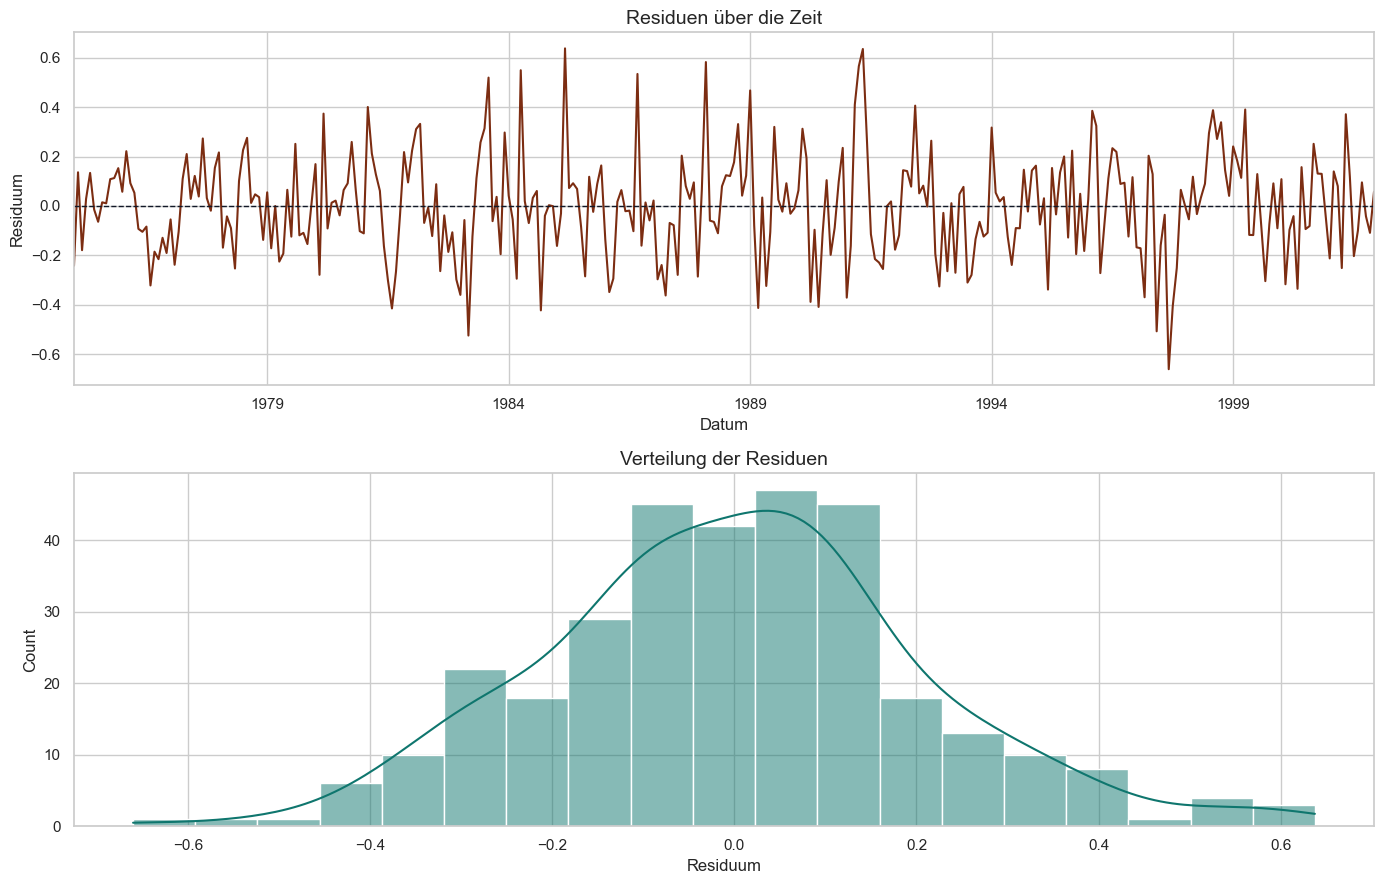

In [168]:
# Plot residuals and their distribution.
fig, axes = plt.subplots(2, 1, figsize=(14, 9))
resid.plot(ax=axes[0], color="#7c2d12", linewidth=1.5)
axes[0].axhline(0, color="#111827", linewidth=1, linestyle="--")
axes[0].set_title("Residuen über die Zeit")
axes[0].set_xlabel("Datum")
axes[0].set_ylabel("Residuum")

sns.histplot(resid, kde=True, ax=axes[1], color="#0f766e")
axes[1].set_title("Verteilung der Residuen")
axes[1].set_xlabel("Residuum")

plt.tight_layout()
plt.show()


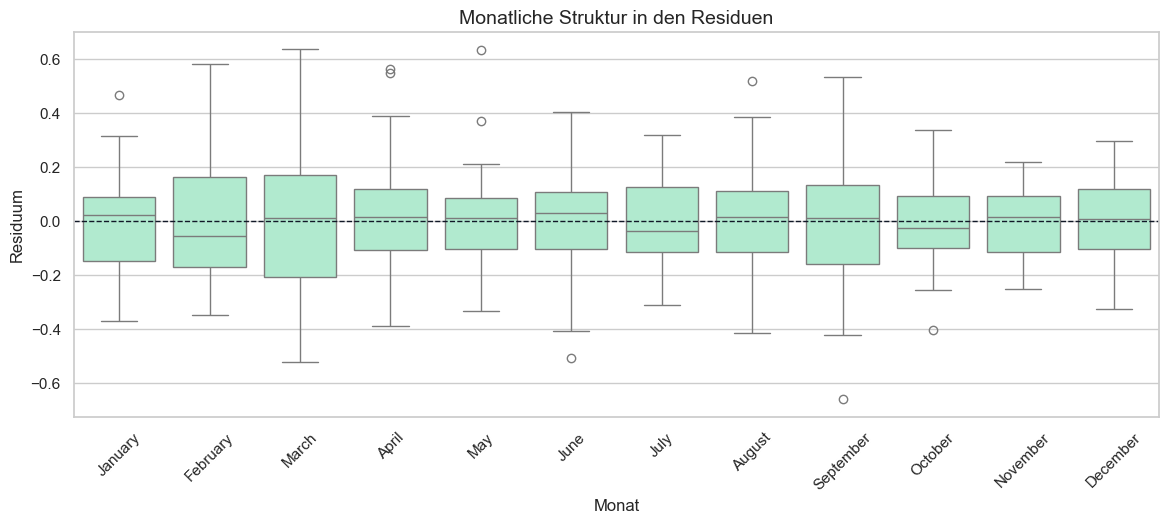

In [169]:
# Check whether residuals still show a monthly pattern.
resid_by_month = pd.DataFrame({
    "resid": resid,
    "month": resid.index.month_name(),
    "month_num": resid.index.month,
}).sort_values("month_num")

fig, ax = plt.subplots(figsize=(14, 5))
sns.boxplot(data=resid_by_month, x="month", y="resid", ax=ax, color="#a7f3d0")
ax.axhline(0, color="#111827", linewidth=1, linestyle="--")
ax.set_title("Monatliche Struktur in den Residuen")
ax.set_xlabel("Monat")
ax.set_ylabel("Residuum")
ax.tick_params(axis="x", rotation=45)
plt.show()

Wenn die Residuen weiterhin starke monatliche Muster zeigen, wäre die saisonale Komponente möglicherweise zu schwach modelliert. Wenn der Trend in den Residuen sichtbar bleibt, wäre die Trendglättung möglicherweise unpassend.

Für das Lernziel dieses Notebooks ist besonders wichtig: Evaluation bedeutet bei STL nicht nur eine Zahl zu berechnen. Evaluation bedeutet, die Komponenten kritisch zu lesen und mit der fachlichen Fragestellung abzugleichen.

## 6. Bereitstellung

Im CRISP-DM-Schritt Bereitstellung geht es darum, die Ergebnisse nutzbar zu machen. Bei STL kann die Bereitstellung je nach Kontext unterschiedlich aussehen:

- Ein Bericht mit Trend-, Saison- und Residualgrafiken.
- Eine saisonbereinigte Zeitreihe für weitere Analysen.
- Ein Monitoring, das ungewöhnliche Residuen als potenzielle Anomalien markiert.
- Ein Vorverarbeitungsschritt für ein Prognosemodell.

Für dieses Notebook speichern wir die wichtigsten Komponenten in einer Tabelle. Diese Tabelle kann anschließend für Berichte, Dashboards oder weitere Modellierungsschritte verwendet werden.

In [170]:
# Prepare a deployable output table with STL components.
deployment_table = components.copy()
deployment_table["seasonally_adjusted"] = deployment_table["observed"] - deployment_table["seasonal"]
deployment_table["residual_abs"] = deployment_table["resid"].abs()
deployment_table["is_large_residual"] = deployment_table["residual_abs"] > deployment_table["residual_abs"].quantile(0.95)

deployment_table.head()

,observed,trend,seasonal,resid,seasonally_adjusted,residual_abs,is_large_residual
1975-01-01,330.250,330.509137,-0.017640,-0.241497,330.267640,0.241497,False
1975-02-01,331.300,330.612902,0.550774,0.136324,330.749226,0.136324,False
1975-03-01,332.000,330.715865,1.462902,-0.178767,330.537098,0.178767,False
1975-04-01,333.275,330.817991,2.428115,0.028893,330.846885,0.028893,False
1975-05-01,333.860,330.919287,2.806956,0.133757,331.053044,0.133757,False


In [171]:
# Save the component table for later use.
output_path = "stl_components_co2.csv"
deployment_table.to_csv(output_path, index_label="date")
print(f"Saved STL component table to: {output_path}")

Saved STL component table to: stl_components_co2.csv


## Zusammenfassung

Dieses Notebook hat die STL-Methode entlang des CRISP-DM-Prozesses aufgebaut.

Im Geschäftsverständnis wurde die fachliche Frage formuliert: Wie trennen wir Trend, Saisonalität und Restschwankungen? Im Datenverständnis wurden Struktur, Frequenz und fehlende Werte betrachtet. In der Datenvorbereitung wurde eine regelmäßige monatliche Zeitreihe erstellt.

Der Modellierungsteil hat gezeigt, dass STL auf LOESS basiert. LOESS nutzt lokale Regressionen, Nachbarschaftsfenster und gewichtete Punkte. Kleine Fenster reagieren flexibel, große Fenster glätten stärker. Anschließend wurde STL schrittweise erklärt: Trend entfernen, Saison schätzen, Saison entfernen, Trend aktualisieren und Residuum berechnen.

Die Parameterstudie hat verdeutlicht, wie `seasonal`, `trend` und `robust` die Zerlegung verändern. Der Vergleich zwischen Standard-STL und robuster STL hat gezeigt, warum robuste Schätzung bei Ausreißern wichtig sein kann.

Die wichtigste Erkenntnis lautet: STL ist nicht nur ein technisches Verfahren, sondern ein interpretierbares Denkwerkzeug für Zeitreihen. Es hilft, eine komplexe Beobachtungsreihe in verständliche Bestandteile zu zerlegen.